# 04. Pytorch custom dataset notebook


## 00. Importing the pytorch library and setup device agnostic code

In [2]:
import torch
from torch import nn






In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
!nvidia-smi

Tue Apr 14 13:44:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   57C    P0             16W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
CUDA version: 11.8
GPU count: 1
GPU name: NVIDIA GeForce GTX 1650 Ti


## 1. get data 

Our dataset is a subset of Food101 dataset  

we use the minimal dataset for training

In [7]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data\pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


## 2. Becoming one with data(data preparation and data exploration)

In [8]:
import os

def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [9]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [10]:
# setup train and test path

train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

Let write some code to:
1. Get all of the image path
2. Pick random image path using python random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working with images, lets open the image with python PIL
5. we will then show the image and print the metadata

In [11]:
image_path

WindowsPath('data/pizza_steak_sushi')

data\pizza_steak_sushi\test\sushi\1434806.jpg
sushi
Random image path: data\pizza_steak_sushi\test\sushi\1434806.jpg
Image class: sushi
Image height: 512
Image width: 512


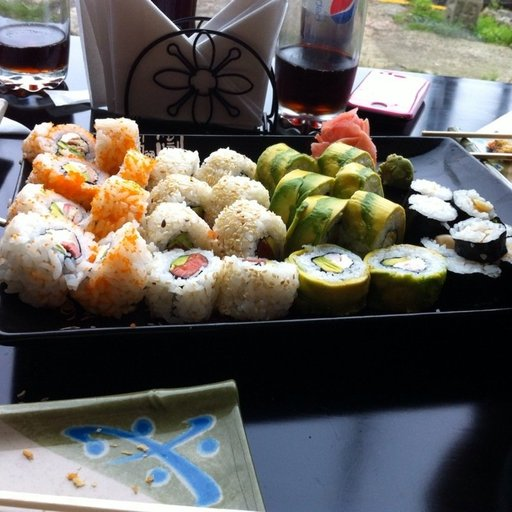

In [62]:
import random
from PIL import Image

#random.seed(42)

#1. Get all the path
image_path_list = list(image_path.glob("*/*/*.jpg"))
#image_path_list

#2. Pick a random image path 
random_image_path = random.choice(image_path_list)
print(random_image_path)

#3. get the image class (the image class is the name of the directory wheree the image is stored)
image_class  = random_image_path.parent.stem
print(image_class)

#4. Open imamge
img = Image.open(random_image_path)

#5. Print metadata of the images
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img



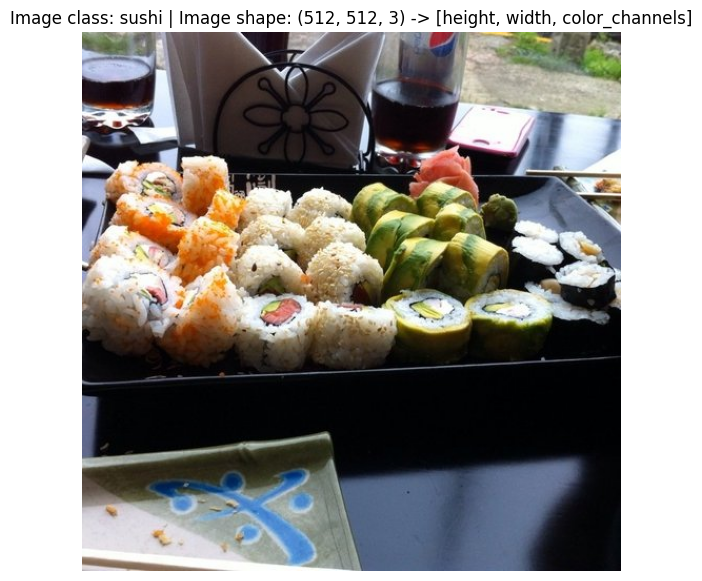

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);    

In [61]:
img_as_array

array([[[  9,  22,  30],
        [  2,  15,  23],
        [  9,  19,  28],
        ...,
        [ 81,  58,  42],
        [109,  78,  58],
        [122,  90,  67]],

       [[ 13,  23,  32],
        [  4,  15,  21],
        [ 12,  21,  28],
        ...,
        [ 80,  57,  41],
        [113,  85,  64],
        [134, 102,  79]],

       [[  7,  16,  23],
        [ 13,  22,  27],
        [ 13,  20,  26],
        ...,
        [ 73,  50,  36],
        [109,  80,  62],
        [134, 103,  82]],

       ...,

       [[ 10,   7,  14],
        [  8,   7,  13],
        [  6,   5,  11],
        ...,
        [173, 132,  68],
        [173, 132,  68],
        [173, 132,  68]],

       [[ 12,   7,  14],
        [  9,   6,  13],
        [  7,   4,  11],
        ...,
        [173, 132,  66],
        [174, 130,  65],
        [173, 129,  64]],

       [[ 12,   7,  14],
        [ 11,   6,  13],
        [  9,   4,  11],
        ...,
        [171, 131,  62],
        [172, 128,  63],
        [170, 126,  61]]